In [1]:
%pip install matplotlib seaborn statsmodels plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


## 1. Importation des données
Nous avons fait le choix de conserver les données de la période après-COVID. L'objectif ici est d'obtenir un résultat concret et non faussé par la crise sanitaire qui a eu lieu. Dans une optique de performance, les lignes des années antérieures à 2021 ont été supprimées via le logiciel "Visual Studio Code" en amont de l'importation.

In [3]:
LFB_MOB1  = pd.read_csv(
    r"C:\Users\anais\OneDrive\Desktop\POMPIERS\LFB_Mobilisation_data_from_2025.csv",
    low_memory=False
)

LFB_MOB1.head()

,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,...,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,01/01/2025 00:02,01/01/2025 00:07,...,01/01/2025 00:23,NaN,H33,Wandsworth,Home Station,2,Initial,Initial Mobilisation,12.0,Not held up
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,01/01/2025 00:02,01/01/2025 00:02,...,01/01/2025 00:38,NaN,G36,Hammersmith,Other Station,1,Initial,Initial Mobilisation,12.0,Not held up
2,000005-01012025,2025,MERTON,WEST BARNES,0,6862259,H401,1,01/01/2025 00:03,01/01/2025 00:04,...,01/01/2025 00:11,NaN,H40,New Malden,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
3,000006-01012025,2025,CROYDON,PURLEY OAKS & RIDDLESDOWN,0,6862260,H291,1,01/01/2025 00:04,01/01/2025 00:06,...,01/01/2025 00:25,NaN,H29,Purley,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
4,000007-01012025,2025,BARNET,BURNT OAK,0,6862261,G222,1,01/01/2025 00:05,01/01/2025 00:06,...,01/01/2025 00:27,NaN,G22,Stanmore,Home Station,1,Initial,Initial Mobilisation,NaN,NaN


In [4]:
LFB_MOB2 = pd.read_csv(
    r"C:\Users\anais\OneDrive\Desktop\POMPIERS\LFB_Mobilisation_data_from_2021-2024.csv",
    low_memory=False
)

LFB_MOB2.head()

,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,...,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description
0,000004-01012021,2021,HARINGEY,Muswell Hill,0,5769249,A321,1,01/01/2021 00:06,01/01/2021 00:07,...,01/01/2021 00:57,NaN,A32,Hornsey,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
1,000005-01012021,2021,REDBRIDGE,MONKHAMS,0,5769250,F351,1,01/01/2021 00:07,01/01/2021 00:09,...,01/01/2021 00:18,NaN,F35,Woodford,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
2,000006-01012021,2021,BARKING AND DAGENHAM,Village,0,5769251,F412,1,01/01/2021 00:08,01/01/2021 00:10,...,01/01/2021 00:24,NaN,F41,Dagenham,Home Station,1,Initial,Initial Mobilisation,12.0,Not held up
3,000007-01012021,2021,WANDSWORTH,West Hill,0,5769252,H331,1,01/01/2021 00:12,01/01/2021 00:13,...,01/01/2021 00:40,NaN,H33,Wandsworth,Home Station,1,Initial,Initial Mobilisation,8.0,Traffic calming measures
4,000007-01012021,2021,WANDSWORTH,West Hill,0,5769253,G351,2,01/01/2021 00:12,01/01/2021 00:13,...,01/01/2021 00:29,NaN,G35,Fulham,Home Station,2,Initial,Initial Mobilisation,NaN,NaN


In [5]:
LFB_INC1 = pd.read_excel(
    r"C:\Users\anais\OneDrive\Desktop\POMPIERS\LFB Incident_data_from_2024_onwards.xlsx"
)

LFB_INC1.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000002-01012024,2024-01-01,2024,00:00:43,0,Special Service,Special Service,Advice Only,Dwelling,Unlicensed House in Multiple Occupation - Up t...,...,172.0,Stratford,289.0,Stratford,2.0,2.0,2,60,388,1.0
1,000003-01012024,2024-01-01,2024,00:01:11,0,Special Service,Special Service,No action (not false alarm),Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,332.0,Shoreditch,NaN,NaN,1.0,1.0,1,60,388,1.0
2,000007-01012024,2024-01-01,2024,00:04:21,0,False Alarm,False alarm - Good intent,NaN,Outdoor,Loose refuse,...,521.0,Lambeth,NaN,NaN,1.0,1.0,1,60,388,1.0
3,000010-01012024,2024-01-01,2024,00:05:40,0,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,NaN,NaN,NaN,NaN,1.0,1.0,1,60,388,1.0
4,000011-01012024,2024-01-01,2024,00:06:32,0,Special Service,Special Service,Effecting entry/exit,Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,323.0,Lee Green,NaN,NaN,1.0,1.0,1,60,388,2.0


In [6]:
LFB_INC2 = pd.read_csv(
    r"C:\Users\anais\OneDrive\Desktop\POMPIERS\LFB_Incidents_2021-2023.csv",
    low_memory=False
)

LFB_INC2.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000004-01012021,2021-01-01,2021,00:06:47,0,False Alarm,AFA,NaN,Non Residential,Single shop,...,181.0,Hornsey,NaN,NaN,1.0,1.0,1,60,346,1.0
1,000005-01012021,2021-01-01,2021,00:07:46,0,Fire,Secondary Fire,NaN,Outdoor,Tree scrub,...,250.0,Woodford,NaN,NaN,1.0,1.0,1,60,346,1.0
2,000006-01012021,2021-01-01,2021,00:08:21,0,False Alarm,False alarm - Good intent,NaN,Outdoor,Road surface/pavement,...,376.0,Dagenham,NaN,NaN,1.0,1.0,1,60,346,1.0
3,000007-01012021,2021-01-01,2021,00:12:16,0,False Alarm,False alarm - Good intent,NaN,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,409.0,Wandsworth,445.0,Fulham,5.0,5.0,5,99,571,4.0
4,000009-01012021,2021-01-01,2021,00:14:51,0,Fire,Primary Fire,NaN,Road Vehicle,Car,...,362.0,Stratford,NaN,NaN,1.0,1.0,1,60,346,2.0


## 2. Exploration des données

Cette étape permet d’examiner la structure, les dimensions et la qualité des quatre jeux de données avant leur nettoyage et leur regroupement.

In [7]:
print("Mobilisations 2025 :", LFB_MOB1.shape)
print("Mobilisations 2021-2024 :", LFB_MOB2.shape)
print("Incidents depuis 2024 :", LFB_INC1.shape)
print("Incidents 2021-2023 :", LFB_INC2.shape)

Mobilisations 2025 : (240744, 24)
Mobilisations 2021-2024 : (727747, 24)
Incidents depuis 2024 : (293646, 39)
Incidents 2021-2023 : (361083, 39)


In [8]:
print("=== MOBILISATIONS 2025 ===")
LFB_MOB1.info()

=== MOBILISATIONS 2025 ===
<class 'pandas.DataFrame'>
RangeIndex: 240744 entries, 0 to 240743
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            240744 non-null  str    
 1   CalYear                   240744 non-null  int64  
 2   BoroughName               239826 non-null  str    
 3   WardName                  239571 non-null  str    
 4   HourOfCall                240744 non-null  int64  
 5   ResourceMobilisationId    240744 non-null  int64  
 6   Resource_Code             240744 non-null  str    
 7   PerformanceReporting      240744 non-null  str    
 8   DateAndTimeMobilised      240744 non-null  str    
 9   DateAndTimeMobile         239646 non-null  str    
 10  DateAndTimeArrived        240744 non-null  str    
 11  TurnoutTimeSeconds        239645 non-null  float64
 12  TravelTimeSeconds         239638 non-null  float64
 13  AttendanceTimeSeconds     24

In [9]:
print("\n=== MOBILISATIONS 2021-2024 ===")
LFB_MOB2.info()


=== MOBILISATIONS 2021-2024 ===
<class 'pandas.DataFrame'>
RangeIndex: 727747 entries, 0 to 727746
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   IncidentNumber            727747 non-null  str    
 1   CalYear                   727747 non-null  int64  
 2   BoroughName               725017 non-null  str    
 3   WardName                  724254 non-null  str    
 4   HourOfCall                727747 non-null  int64  
 5   ResourceMobilisationId    727747 non-null  int64  
 6   Resource_Code             727747 non-null  str    
 7   PerformanceReporting      727747 non-null  str    
 8   DateAndTimeMobilised      727747 non-null  str    
 9   DateAndTimeMobile         724545 non-null  str    
 10  DateAndTimeArrived        727747 non-null  str    
 11  TurnoutTimeSeconds        724526 non-null  float64
 12  TravelTimeSeconds         724521 non-null  float64
 13  AttendanceTimeSeconds 

In [10]:
print("\n=== INCIDENTS DEPUIS 2024 ===")
LFB_INC1.info()


=== INCIDENTS DEPUIS 2024 ===
<class 'pandas.DataFrame'>
RangeIndex: 293646 entries, 0 to 293645
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          293646 non-null  str           
 1   DateOfCall                              293646 non-null  datetime64[us]
 2   CalYear                                 293646 non-null  int64         
 3   TimeOfCall                              293646 non-null  object        
 4   HourOfCall                              293646 non-null  int64         
 5   IncidentGroup                           293592 non-null  str           
 6   StopCodeDescription                     293646 non-null  str           
 7   SpecialServiceType                      119083 non-null  str           
 8   PropertyCategory                        293635 non-null  str           
 9   PropertyType     

In [11]:
print("\n=== INCIDENTS 2021-2023 ===")
LFB_INC2.info()


=== INCIDENTS 2021-2023 ===
<class 'pandas.DataFrame'>
RangeIndex: 361083 entries, 0 to 361082
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   IncidentNumber                          361083 non-null  str    
 1   DateOfCall                              361083 non-null  str    
 2   CalYear                                 361083 non-null  int64  
 3   TimeOfCall                              361083 non-null  str    
 4   HourOfCall                              361083 non-null  int64  
 5   IncidentGroup                           361083 non-null  str    
 6   StopCodeDescription                     361083 non-null  str    
 7   SpecialServiceType                      135045 non-null  str    
 8   PropertyCategory                        361083 non-null  str    
 9   PropertyType                            361083 non-null  str    
 10  AddressQualifier          

### 2.1 Structure et types des données

Le but de l'inspection des données est de comprendre l'ampleur du pourcentage de valeurs manquantes ou distinctes, afin de mieux comprendre la base de données.
Cette étape constitue une phase essentielle du prétraitement. Elle permet de mieux comprendre la structure, le contenu et la qualité des différents jeux de données utilisés.
Concrètement, cette phase consiste à examiner les dimensions des DataFrames, les types de variables, ainsi que les premières observations afin d’avoir un aperçu global des informations disponibles. Une attention particulière est également portée à la détection de valeurs manquantes, de doublons ou d’éventuelles incohérences dans les données.
Nous l'avons appliquée de manière identique aux différentes sources de données, pour s’assurer de leur cohérence et pour guider les étapes suivantes de nettoyage, de transformation et d’analyse.


In [12]:
print("\nPourcentage de valeurs manquantes :")

valeurs_manquantes_MOB1 = (
    LFB_MOB1.isnull().sum()
    .div(len(LFB_MOB1))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

valeurs_manquantes_MOB1



Pourcentage de valeurs manquantes :


DateAndTimeReturned         100.00
DelayCodeId                  72.34
DelayCode_Description        72.34
WardName                      0.49
DateAndTimeMobile             0.46
TravelTimeSeconds             0.46
TurnoutTimeSeconds            0.46
BoroughName                   0.38
DeployedFromLocation          0.21
DateAndTimeLeft               0.05
PerformanceReporting          0.00
Resource_Code                 0.00
IncidentNumber                0.00
CalYear                       0.00
ResourceMobilisationId        0.00
HourOfCall                    0.00
AttendanceTimeSeconds         0.00
DateAndTimeArrived            0.00
DateAndTimeMobilised          0.00
DeployedFromStation_Code      0.00
PumpOrder                     0.00
DeployedFromStation_Name      0.00
PlusCode_Description          0.00
PlusCode_Code                 0.00
dtype: float64

In [13]:
print("=== Nombre de valeurs distinctes : ===")

LFB_MOB1[
    [
        "IncidentNumber",
        "BoroughName",
        "WardName",
        "Resource_Code",
        "PerformanceReporting",
        "DateAndTimeMobilised",
        "DateAndTimeMobile",
        "DateAndTimeArrived",
        "DateAndTimeLeft",
        "DateAndTimeReturned",
        "DeployedFromStation_Code",
        "DeployedFromStation_Name",
        "DeployedFromLocation",
        "PlusCode_Code",
        "PlusCode_Description",
        "DelayCode_Description"
    ]
].nunique()

=== Nombre de valeurs distinctes : ===


IncidentNumber              151689
BoroughName                     34
WardName                       693
Resource_Code                  142
PerformanceReporting             3
DateAndTimeMobilised        135952
DateAndTimeMobile           158354
DateAndTimeArrived          176220
DateAndTimeLeft             181812
DateAndTimeReturned              1
DeployedFromStation_Code       111
DeployedFromStation_Name       111
DeployedFromLocation             2
PlusCode_Code                    1
PlusCode_Description             1
DelayCode_Description           10
dtype: int64

In [14]:
print("\nPourcentage de valeurs manquantes :")

valeurs_manquantes_MOB2 = (
    LFB_MOB2.isnull().sum()
    .div(len(LFB_MOB2))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

valeurs_manquantes_MOB2


Pourcentage de valeurs manquantes :


DateAndTimeReturned         100.00
DelayCodeId                  74.84
DelayCode_Description        74.84
WardName                      0.48
DateAndTimeMobile             0.44
TravelTimeSeconds             0.44
TurnoutTimeSeconds            0.44
BoroughName                   0.38
DeployedFromLocation          0.07
DateAndTimeLeft               0.04
PerformanceReporting          0.00
Resource_Code                 0.00
IncidentNumber                0.00
CalYear                       0.00
ResourceMobilisationId        0.00
HourOfCall                    0.00
AttendanceTimeSeconds         0.00
DateAndTimeArrived            0.00
DateAndTimeMobilised          0.00
DeployedFromStation_Code      0.00
PumpOrder                     0.00
DeployedFromStation_Name      0.00
PlusCode_Description          0.00
PlusCode_Code                 0.00
dtype: float64

In [15]:
print("=== Nombre de valeurs distinctes : ===")

LFB_MOB2[
    ["IncidentNumber", "BoroughName", "WardName",
 "Resource_Code", "PerformanceReporting", "DateAndTimeMobilised",
 "DateAndTimeMobile", "DateAndTimeArrived", "DateAndTimeLeft",
 "DateAndTimeReturned", "DeployedFromStation_Code", "DeployedFromStation_Name",
 "DeployedFromLocation", "PlusCode_Code", "PlusCode_Description", "DelayCode_Description"
 ]
].nunique()

=== Nombre de valeurs distinctes : ===


IncidentNumber              469672
BoroughName                     37
WardName                      1283
Resource_Code                  142
PerformanceReporting             3
DateAndTimeMobilised        424135
DateAndTimeMobile           489857
DateAndTimeArrived          546403
DateAndTimeLeft             563166
DateAndTimeReturned              0
DeployedFromStation_Code       110
DeployedFromStation_Name       110
DeployedFromLocation             2
PlusCode_Code                    1
PlusCode_Description             1
DelayCode_Description           10
dtype: int64

In [16]:
print("\nPourcentage de valeurs manquantes :")

valeurs_manquantes_INC1 = (
    LFB_INC1.isnull().sum()
    .div(len(LFB_INC1))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

valeurs_manquantes_INC1


Pourcentage de valeurs manquantes :


SecondPumpArriving_AttendanceTime         63.04
SecondPumpArriving_DeployedFromStation    63.04
Northing_m                                62.07
Easting_m                                 62.07
Postcode_full                             62.07
Longitude                                 62.07
Latitude                                  62.07
SpecialServiceType                        59.45
FirstPumpArriving_DeployedFromStation      5.17
FirstPumpArriving_AttendanceTime           5.17
NumStationsWithPumpsAttending              1.09
NumPumpsAttending                          1.09
IncGeo_WardNameNew                         0.18
IncGeo_WardName                            0.18
IncGeo_WardCode                            0.18
IncidentGroup                              0.02
HourOfCall                                 0.00
StopCodeDescription                        0.00
CalYear                                    0.00
IncidentNumber                             0.00
DateOfCall                              

In [17]:
print("=== Nombre de valeurs distinctes :=== ")
LFB_INC1[["IncidentNumber","TimeOfCall","IncidentGroup",
 "StopCodeDescription","SpecialServiceType","PropertyCategory",
 "PropertyType","AddressQualifier","Postcode_full","Postcode_district",
 "IncGeo_BoroughCode","IncGeo_BoroughName","ProperCase",
 "IncGeo_WardCode","IncGeo_WardName","IncGeo_WardNameNew","FRS",
 "IncidentStationGround","FirstPumpArriving_DeployedFromStation","SecondPumpArriving_DeployedFromStation"]].nunique()


=== Nombre de valeurs distinctes :=== 


IncidentNumber                            293646
TimeOfCall                                 80620
IncidentGroup                                  3
StopCodeDescription                           12
SpecialServiceType                            20
PropertyCategory                               9
PropertyType                                 280
AddressQualifier                              11
Postcode_full                              43714
Postcode_district                            308
IncGeo_BoroughCode                            33
IncGeo_BoroughName                            33
ProperCase                                    33
IncGeo_WardCode                              704
IncGeo_WardName                              693
IncGeo_WardNameNew                           693
FRS                                            1
IncidentStationGround                        102
FirstPumpArriving_DeployedFromStation        104
SecondPumpArriving_DeployedFromStation       104
dtype: int64

In [18]:
print("\nPourcentage de valeurs manquantes :")

valeurs_manquantes_INC2 = (
    LFB_INC2.isnull().sum()
    .div(len(LFB_INC2))
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

valeurs_manquantes_INC2


Pourcentage de valeurs manquantes :


SecondPumpArriving_AttendanceTime         64.62
SecondPumpArriving_DeployedFromStation    64.62
SpecialServiceType                        62.60
Postcode_full                             57.43
Northing_m                                57.43
Longitude                                 57.43
Latitude                                  57.43
Easting_m                                 57.43
FirstPumpArriving_DeployedFromStation      5.89
FirstPumpArriving_AttendanceTime           5.89
NumStationsWithPumpsAttending              1.53
NumPumpsAttending                          1.53
IncGeo_WardNameNew                         0.06
IncGeo_WardName                            0.06
IncGeo_WardCode                            0.06
StopCodeDescription                        0.00
IncidentGroup                              0.00
HourOfCall                                 0.00
TimeOfCall                                 0.00
CalYear                                    0.00
DateOfCall                              

In [19]:
print("Nombre de valeurs distinctes :")
LFB_INC2[["IncidentNumber","TimeOfCall","IncidentGroup",
 "StopCodeDescription","SpecialServiceType","PropertyCategory",
 "PropertyType","AddressQualifier","Postcode_full","Postcode_district",
 "IncGeo_BoroughCode","IncGeo_BoroughName","ProperCase","IncGeo_WardCode",
 "IncGeo_WardName","IncGeo_WardNameNew","FRS","IncidentStationGround",
 "FirstPumpArriving_DeployedFromStation","SecondPumpArriving_DeployedFromStation"]].nunique()

Nombre de valeurs distinctes :


IncidentNumber                            361083
TimeOfCall                                 82779
IncidentGroup                                  3
StopCodeDescription                           10
SpecialServiceType                            20
PropertyCategory                               9
PropertyType                                 284
AddressQualifier                              11
Postcode_full                              51634
Postcode_district                            303
IncGeo_BoroughCode                            33
IncGeo_BoroughName                            33
ProperCase                                    33
IncGeo_WardCode                              736
IncGeo_WardName                             1282
IncGeo_WardNameNew                          1282
FRS                                            1
IncidentStationGround                        103
FirstPumpArriving_DeployedFromStation        105
SecondPumpArriving_DeployedFromStation       102
dtype: int64

## 3. Nettoyage des données

La phase de nettoyage des données vise à préparer les jeux de données pour les analyses futures en garantissant leur qualité et leur cohérence.
Dans cette étape, les DataFrames issus de sources similaires sont d’abord regroupés afin de constituer des ensembles de données homogènes et exploitables. Ensuite, un traitement des valeurs manquantes (NaN) est réalisé, soit par suppression, soit par remplacement, en fonction de leur impact sur l’analyse.
Enfin, les colonnes jugées inutiles ou redondantes sont supprimées afin d’alléger les jeux de données et de ne conserver que les variables pertinentes. Cette phase permet ainsi d’obtenir des données plus fiables, structurées et adaptées aux traitements analytiques à venir.


### 3.1 Concatenation 

In [20]:
LFB_MOB = pd.concat([LFB_MOB1, LFB_MOB2], ignore_index=True)
LFB_MOB.head()

,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeMobile,...,DateAndTimeLeft,DateAndTimeReturned,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,01/01/2025 00:02,01/01/2025 00:07,...,01/01/2025 00:23,NaN,H33,Wandsworth,Home Station,2,Initial,Initial Mobilisation,12.0,Not held up
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,01/01/2025 00:02,01/01/2025 00:02,...,01/01/2025 00:38,NaN,G36,Hammersmith,Other Station,1,Initial,Initial Mobilisation,12.0,Not held up
2,000005-01012025,2025,MERTON,WEST BARNES,0,6862259,H401,1,01/01/2025 00:03,01/01/2025 00:04,...,01/01/2025 00:11,NaN,H40,New Malden,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
3,000006-01012025,2025,CROYDON,PURLEY OAKS & RIDDLESDOWN,0,6862260,H291,1,01/01/2025 00:04,01/01/2025 00:06,...,01/01/2025 00:25,NaN,H29,Purley,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
4,000007-01012025,2025,BARNET,BURNT OAK,0,6862261,G222,1,01/01/2025 00:05,01/01/2025 00:06,...,01/01/2025 00:27,NaN,G22,Stanmore,Home Station,1,Initial,Initial Mobilisation,NaN,NaN


In [21]:
# Uniformisation des noms des colonnes similaires avant concaténation
LFB_INC2 = LFB_INC2.rename(columns={"Notional Cost (Â£)": "Notional Cost (£)"})

In [22]:
LFB_INC = pd.concat([LFB_INC1, LFB_INC2], ignore_index=True)
LFB_INC.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000002-01012024,2024-01-01 00:00:00,2024,00:00:43,0,Special Service,Special Service,Advice Only,Dwelling,Unlicensed House in Multiple Occupation - Up t...,...,172.0,Stratford,289.0,Stratford,2.0,2.0,2,60,388,1.0
1,000003-01012024,2024-01-01 00:00:00,2024,00:01:11,0,Special Service,Special Service,No action (not false alarm),Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,332.0,Shoreditch,NaN,NaN,1.0,1.0,1,60,388,1.0
2,000007-01012024,2024-01-01 00:00:00,2024,00:04:21,0,False Alarm,False alarm - Good intent,NaN,Outdoor,Loose refuse,...,521.0,Lambeth,NaN,NaN,1.0,1.0,1,60,388,1.0
3,000010-01012024,2024-01-01 00:00:00,2024,00:05:40,0,Special Service,Special Service,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,NaN,NaN,NaN,NaN,1.0,1.0,1,60,388,1.0
4,000011-01012024,2024-01-01 00:00:00,2024,00:06:32,0,Special Service,Special Service,Effecting entry/exit,Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,323.0,Lee Green,NaN,NaN,1.0,1.0,1,60,388,2.0


### 3.2 Ajustement de la période étudiée et vérification 

In [23]:
# Suppression des lignes postérieurs à 2025 (l'année 2026 n'étant pas complète).
# MOBILISATION - "MOB"
LFB_MOB = LFB_MOB[LFB_MOB["CalYear"] < 2026]
print("Vérification pour MOB", LFB_MOB["CalYear"].unique())
# INCIDENTS - "INC"
LFB_INC = LFB_INC[LFB_INC['CalYear'] < 2026]
print("Vérification pour INC",LFB_MOB["CalYear"].unique())


Vérification pour MOB [2025 2021 2022 2023 2024]
Vérification pour INC [2025 2021 2022 2023 2024]


### 3.3 Suppression de colonnes
Le choix des colonnes à supprimer, dépend de leur contenu (exemple : majorité de données manquantes "NaN", donnée unique,etc...). Ici, nous avons souhaité conserver uniquement les colonnes utiles à l'analyse des temps, des lieux et raisons des déplacements des brigades de pompiers de Londres.

In [24]:
LFB_MOB = LFB_MOB.drop(columns=["DateAndTimeMobile","DateAndTimeReturned"])
LFB_MOB.head()

,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeArrived,...,AttendanceTimeSeconds,DateAndTimeLeft,DeployedFromStation_Code,DeployedFromStation_Name,DeployedFromLocation,PumpOrder,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,01/01/2025 00:02,01/01/2025 00:13,...,621,01/01/2025 00:23,H33,Wandsworth,Home Station,2,Initial,Initial Mobilisation,12.0,Not held up
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,01/01/2025 00:02,01/01/2025 00:12,...,563,01/01/2025 00:38,G36,Hammersmith,Other Station,1,Initial,Initial Mobilisation,12.0,Not held up
2,000005-01012025,2025,MERTON,WEST BARNES,0,6862259,H401,1,01/01/2025 00:03,01/01/2025 00:06,...,168,01/01/2025 00:11,H40,New Malden,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
3,000006-01012025,2025,CROYDON,PURLEY OAKS & RIDDLESDOWN,0,6862260,H291,1,01/01/2025 00:04,01/01/2025 00:09,...,251,01/01/2025 00:25,H29,Purley,Home Station,1,Initial,Initial Mobilisation,NaN,NaN
4,000007-01012025,2025,BARNET,BURNT OAK,0,6862261,G222,1,01/01/2025 00:05,01/01/2025 00:10,...,313,01/01/2025 00:27,G22,Stanmore,Home Station,1,Initial,Initial Mobilisation,NaN,NaN


### 3.4 Gestion des NaN

Les valeurs manquantes (NaN) du DataFrame "MOB" correspondent à des quartiers d'intervention non renseignés ou des informations non renseignées. Nous avons fait le choix de remplacer ces NaN par des nouvelles catégories de valeurs plus explicites

In [25]:
# Remplacement des valeurs manquantes dans les colonnes textuelles
LFB_MOB = LFB_MOB.fillna({
    "BoroughName": "Non renseigné",
    "WardName": "Non renseigné",
    "DeployedFromLocation": "Non renseigné",
    "DelayCode_Description": "No delay"
})

# Remplacement des valeurs manquantes numériques par la médiane
LFB_MOB["TurnoutTimeSeconds"] = (
    LFB_MOB["TurnoutTimeSeconds"]
    .fillna(LFB_MOB["TurnoutTimeSeconds"].median())
)

LFB_MOB["TravelTimeSeconds"] = (
    LFB_MOB["TravelTimeSeconds"]
    .fillna(LFB_MOB["TravelTimeSeconds"].median())
)

# Code 0 pour indiquer l’absence de retard
LFB_MOB["DelayCodeId"] = (
    LFB_MOB["DelayCodeId"]
    .fillna(0)
    .astype("int64")
)

# DateAndTimeLeft reste vide lorsque l’information est absente,
# afin de conserver un véritable type date

# Vérification des valeurs manquantes restantes
LFB_MOB.isnull().sum().sort_values(ascending=False)

DateAndTimeLeft             384
DeployedFromStation_Code      5
DeployedFromStation_Name      5
BoroughName                   0
IncidentNumber                0
CalYear                       0
ResourceMobilisationId        0
HourOfCall                    0
WardName                      0
Resource_Code                 0
DateAndTimeArrived            0
TurnoutTimeSeconds            0
DateAndTimeMobilised          0
PerformanceReporting          0
AttendanceTimeSeconds         0
TravelTimeSeconds             0
DeployedFromLocation          0
PumpOrder                     0
PlusCode_Code                 0
PlusCode_Description          0
DelayCodeId                   0
DelayCode_Description         0
dtype: int64

Les valeurs manquantes (NaN) du DataFrame « INC » correspondent à des actions qui n’ont pas été nécessaires lors d’une mobilisation. Il est donc important de les conserver, tout en les catégorisant afin de pouvoir les comptabiliser.
Pour les variables présentant un taux de valeurs manquantes inférieur à 1 % (par exemple : incident non renseigné, lieu non indiqué, etc.), nous avons choisi de les remplacer par la valeur la plus fréquente de la colonne concernée. Cette approche permet de préserver la qualité des données tout en évitant d’introduire des biais susceptibles d’affecter les analyses ultérieures.


#### Traitement de la ligne "Notional Cost (£)"

502.2052594506494
388.0
IQR ratio: 1.27
________________________________________________________________




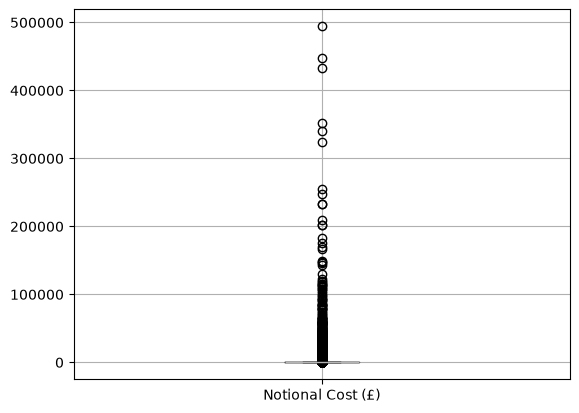

In [26]:

# Calcul de la moyenne
moyenne_Notional_Cost = LFB_INC["Notional Cost (£)"].mean()
print(moyenne_Notional_Cost)
# Calcul de la médianne
mediane_Notional_Cost = LFB_INC["Notional Cost (£)"].median()
print(mediane_Notional_Cost)
# Vérification
Q1 = LFB_INC["Notional Cost (£)"].quantile(0.25)
Q3 = LFB_INC["Notional Cost (£)"].quantile(0.75)
print(f"IQR ratio: {Q3/Q1:.2f}")
print("________________________________________________________________""\n""\n")
# Visualisation des résultats
LFB_INC.boxplot(column="Notional Cost (£)");

Nous pouvons retenir la moyenne (502 £) car ratio IQR faible (<1.5). Toutefois, présence d'outliers certainement dû à des incidents très couteux (ex : Gros incendie) mais qui restent non significatifs dans la masse. Les NaN de la colonne "Notional Cost (£)" seront remplacés par 502

In [27]:
# Remplacement des NaN de la colonne "Notional Cost (£)" par la moyenne
LFB_INC["Notional Cost (£)"] = LFB_INC["Notional Cost (£)"].fillna(502)
# Vérification
print(LFB_INC["Notional Cost (£)"].isna().sum())

0


#### Traitement de la colonne "SecondPumpArriving_AttendanceTime

In [28]:
# Calcul de la moyenne
moyenne_Second_Pump = LFB_INC["SecondPumpArriving_AttendanceTime"].mean()
print(moyenne_Second_Pump)
# Calcul de la médianne
mediane_Second_Pump = LFB_INC["SecondPumpArriving_AttendanceTime"].median()
print(mediane_Second_Pump)
# Vérification
Q1 = LFB_INC["SecondPumpArriving_AttendanceTime"].quantile(0.25)
Q3 = LFB_INC["SecondPumpArriving_AttendanceTime"].quantile(0.75)
print(f"IQR ratio: {Q3/Q1:.2f}")
print("________________________________________________________________""\n""\n")

403.18981788188427
381.0
IQR ratio: 1.54
________________________________________________________________




Les valeurs manquantes de `SecondPumpArriving_AttendanceTime` sont conservées, car elles correspondent principalement aux incidents ne nécessitant pas de deuxième véhicule. Elles sont uniquement exclues des calculs portant sur le temps d’arrivée du deuxième véhicule.

In [29]:
# Vérification
print(LFB_INC["SecondPumpArriving_AttendanceTime"].isna().sum())

405255


#### Traitement général des colonnes

In [30]:
# Les colonnes ayant des valeurs manquantes inférieurs à 1% ont été remplacées par la catégorie la plus rensegnée de la colonne
LFB_INC = LFB_INC.fillna({
 "IncidentGroup" : "False Alarm",
 "SpecialServiceType" : "No service type",
 "IncGeo_WardNameNew" : "WEST END",
 "SecondPumpArriving_DeployedFromStation" : "No second pump",
 "NumStationsWithPumpsAttending" : "0",
 "NumPumpsAttending" : "0"})

In [31]:
# Les colonnes "FirstPumpArriving_AttendanceTime" et "FirstPumpArriving_DeployedFromStation" possèdent moins de 6% de NaN.
# Nous préférons supprimer les lignes ayant des valeurs manquantes, pour ne pas compromettre les calculs à venir des données.
LFB_INC = LFB_INC.dropna(subset=["FirstPumpArriving_AttendanceTime"])
LFB_INC = LFB_INC.dropna(subset=["FirstPumpArriving_DeployedFromStation"])
LFB_INC.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000002-01012024,2024-01-01 00:00:00,2024,00:00:43,0,Special Service,Special Service,Advice Only,Dwelling,Unlicensed House in Multiple Occupation - Up t...,...,172.0,Stratford,289.0,Stratford,2.0,2.0,2,60,388,1.0
1,000003-01012024,2024-01-01 00:00:00,2024,00:01:11,0,Special Service,Special Service,No action (not false alarm),Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,332.0,Shoreditch,NaN,No second pump,1.0,1.0,1,60,388,1.0
2,000007-01012024,2024-01-01 00:00:00,2024,00:04:21,0,False Alarm,False alarm - Good intent,No service type,Outdoor,Loose refuse,...,521.0,Lambeth,NaN,No second pump,1.0,1.0,1,60,388,1.0
4,000011-01012024,2024-01-01 00:00:00,2024,00:06:32,0,Special Service,Special Service,Effecting entry/exit,Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,323.0,Lee Green,NaN,No second pump,1.0,1.0,1,60,388,2.0
5,000012-01012024,2024-01-01 00:00:00,2024,00:06:39,0,Fire,Secondary Fire,No service type,Outdoor,Road surface/pavement,...,208.0,Holloway,NaN,No second pump,1.0,1.0,1,60,388,1.0


In [32]:
print("Vérification du traitement des valeurs manquantes :")
(LFB_INC.isnull().sum() / len(LFB_INC)) * 100

Vérification du traitement des valeurs manquantes :


IncidentNumber                             0.000000
DateOfCall                                 0.000000
CalYear                                    0.000000
TimeOfCall                                 0.000000
HourOfCall                                 0.000000
IncidentGroup                              0.000000
StopCodeDescription                        0.000000
SpecialServiceType                         0.000000
PropertyCategory                           0.000000
PropertyType                               0.000000
AddressQualifier                           0.000000
Postcode_full                             58.446769
Postcode_district                          0.000000
UPRN                                       0.000000
USRN                                       0.000000
IncGeo_BoroughCode                         0.000000
IncGeo_BoroughName                         0.000000
ProperCase                                 0.000000
IncGeo_WardCode                            0.118913
IncGeo_WardN

## 4. Transformation 
La transformation des DataFrame a pour but de clarifier les données renseignées. Les types (int64, object, float) de certaines colonnes doivent être modifiés pour un meilleur traitement de l'information.
Le but ici est de procéder à tous les changements (division de colonne, etc...) nécessaires à une parfaite utilisation des données.
Dans un premier temps, l'uniformisation des données (date et heure) est nécessaire pour que l'ensemble des informations soient exploitables.


#### MOB - Création des nouvelles colonnes et uniformisation

#### Traitement des dates

Les colonnes temporelles ont été converties au format `datetime`.  
La colonne `DateAndTimeLeft` contient 384 valeurs manquantes. Elles sont conservées sous forme `NaT` afin de ne pas introduire de dates artificielles susceptibles de fausser les calculs de durée.

In [33]:
# uniformisation 
colonnes_dates_MOB = [
    "DateAndTimeMobilised",
    "DateAndTimeArrived",
    "DateAndTimeLeft"
]

for col in colonnes_dates_MOB:
    LFB_MOB[col] = pd.to_datetime(
        LFB_MOB[col],
        format="mixed",
        dayfirst=True,
        errors="coerce"
    )

In [34]:
LFB_MOB[colonnes_dates_MOB].isnull().sum()

DateAndTimeMobilised      0
DateAndTimeArrived        0
DateAndTimeLeft         384
dtype: int64

In [35]:
# Création des colonnes de date et d’heure

LFB_MOB["DateMobilised"] = (
    LFB_MOB["DateAndTimeMobilised"].dt.date
)
LFB_MOB["TimeMobilised"] = (
    LFB_MOB["DateAndTimeMobilised"].dt.time
)

LFB_MOB["DateArrived"] = (
    LFB_MOB["DateAndTimeArrived"].dt.date
)
LFB_MOB["TimeArrived"] = (
    LFB_MOB["DateAndTimeArrived"].dt.time
)

LFB_MOB["DateLeft"] = (
    LFB_MOB["DateAndTimeLeft"].dt.date
)
LFB_MOB["TimeLeft"] = (
    LFB_MOB["DateAndTimeLeft"].dt.time
)

LFB_MOB.head()

,IncidentNumber,CalYear,BoroughName,WardName,HourOfCall,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeArrived,...,PlusCode_Code,PlusCode_Description,DelayCodeId,DelayCode_Description,DateMobilised,TimeMobilised,DateArrived,TimeArrived,DateLeft,TimeLeft
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,2025-01-01 00:02:00,2025-01-01 00:13:00,...,Initial,Initial Mobilisation,12,Not held up,2025-01-01,00:02:00,2025-01-01,00:13:00,2025-01-01,00:23:00
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,2025-01-01 00:02:00,2025-01-01 00:12:00,...,Initial,Initial Mobilisation,12,Not held up,2025-01-01,00:02:00,2025-01-01,00:12:00,2025-01-01,00:38:00
2,000005-01012025,2025,MERTON,WEST BARNES,0,6862259,H401,1,2025-01-01 00:03:00,2025-01-01 00:06:00,...,Initial,Initial Mobilisation,0,No delay,2025-01-01,00:03:00,2025-01-01,00:06:00,2025-01-01,00:11:00
3,000006-01012025,2025,CROYDON,PURLEY OAKS & RIDDLESDOWN,0,6862260,H291,1,2025-01-01 00:04:00,2025-01-01 00:09:00,...,Initial,Initial Mobilisation,0,No delay,2025-01-01,00:04:00,2025-01-01,00:09:00,2025-01-01,00:25:00
4,000007-01012025,2025,BARNET,BURNT OAK,0,6862261,G222,1,2025-01-01 00:05:00,2025-01-01 00:10:00,...,Initial,Initial Mobilisation,0,No delay,2025-01-01,00:05:00,2025-01-01,00:10:00,2025-01-01,00:27:00


#### Uniformisation 

In [36]:
LFB_INC["DateOfCall"] = pd.to_datetime(
    LFB_INC["DateOfCall"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

#### MOB et INC - Jonction via la clé "IncidentNumber"

In [37]:
LFB_Merge = LFB_MOB.merge(LFB_INC, on="IncidentNumber", how="left")
LFB_Merge.info()
LFB_Merge.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 935716 entries, 0 to 935715
Data columns (total 66 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          935716 non-null  str           
 1   CalYear_x                               935716 non-null  int64         
 2   BoroughName                             935716 non-null  str           
 3   WardName                                935716 non-null  str           
 4   HourOfCall_x                            935716 non-null  int64         
 5   ResourceMobilisationId                  935716 non-null  int64         
 6   Resource_Code                           935716 non-null  str           
 7   PerformanceReporting                    935716 non-null  str           
 8   DateAndTimeMobilised                    935716 non-null  datetime64[us]
 9   DateAndTimeArrived                      935716 n

,IncidentNumber,CalYear_x,BoroughName,WardName,HourOfCall_x,ResourceMobilisationId,Resource_Code,PerformanceReporting,DateAndTimeMobilised,DateAndTimeArrived,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862256,H331,2,2025-01-01 00:02:00,2025-01-01 00:13:00,...,563.0,Hammersmith,621.0,Wandsworth,2.0,2.0,2.0,60.0,430.0,1.0
1,000004-01012025,2025,HAMMERSMITH AND FULHAM,FULHAM REACH,0,6862257,G261,1,2025-01-01 00:02:00,2025-01-01 00:12:00,...,563.0,Hammersmith,621.0,Wandsworth,2.0,2.0,2.0,60.0,430.0,1.0


In [38]:
print("Nombre de lignes MOB :", len(LFB_MOB))
print("Nombre de lignes INC :", len(LFB_INC))
print("Nombre de lignes après fusion :", len(LFB_Merge))

print(
    "Incidents uniques dans MOB :",
    LFB_MOB["IncidentNumber"].nunique()
)

print(
    "Incidents uniques dans INC :",
    LFB_INC["IncidentNumber"].nunique()
)

print(
    "Doublons IncidentNumber dans INC :",
    LFB_INC["IncidentNumber"].duplicated().sum()
)

Nombre de lignes MOB : 935716
Nombre de lignes INC : 597915
Nombre de lignes après fusion : 935716
Incidents uniques dans MOB : 600903
Incidents uniques dans INC : 597915
Doublons IncidentNumber dans INC : 0


In [39]:
print(
    "Coûts manquants dans INC :",
    LFB_INC["Notional Cost (£)"].isnull().sum()
)

print(
    "Incidents sans coût après fusion :",
    LFB_Merge.loc[
        LFB_Merge["Notional Cost (£)"].isnull(),
        "IncidentNumber"
    ].nunique()
)

Coûts manquants dans INC : 0
Incidents sans coût après fusion : 3414


#### Contrôle de la fusion

La table des incidents ne contient aucun coût manquant. Cependant, certains identifiants présents dans les mobilisations ne trouvent pas de correspondance dans la table des incidents. Les coûts associés restent donc manquants après la jointure et ne sont pas remplacés artificiellement par zéro.

## 5. Statistiques
L'analyse statistique d'une base de données vise à comprendre les données avant modélisation et à extraire des insights actionnables.
Objectifs principaux :
Résumer les caractéristiques (moyennes, distributions, cardinalité). Détecter les problèmes : NaN (50% coûts), outliers, doublons.
Identifier patterns/relations (corrélations borough-coûts LFB).
Préparer les données : imputation, feature engineering


#### 5.1 Zoom sur les temps d'interventions
Cette partie étudie le délai de mobilisation, le temps de trajet et le temps total nécessaire aux ressources pour arriver sur le lieu de l’incident.

In [40]:
colonnes_temps = [
    "TurnoutTimeSeconds",
    "TravelTimeSeconds",
    "AttendanceTimeSeconds"
]

statistiques_temps = (
    LFB_MOB[colonnes_temps]
    .describe()
    .round(2)
)

statistiques_temps

,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds
count,935716.00,935716.0,935716.00
mean,74.37,287.7,361.06
std,41.13,151.3,154.17
min,0.00,0.0,0.00
25%,52.00,186.0,259.00
50%,71.00,263.0,338.00
75%,91.00,360.0,436.00
max,1192.00,1187.0,1200.00


In [41]:
valeurs_zero = pd.DataFrame({
    "Nombre de zéros": (LFB_MOB[colonnes_temps] == 0).sum(),
    "Pourcentage de zéros": (
        (LFB_MOB[colonnes_temps] == 0).mean() * 100
    ).round(2)
})

valeurs_zero

,Nombre de zéros,Pourcentage de zéros
TurnoutTimeSeconds,24,0.00
TravelTimeSeconds,610,0.07
AttendanceTimeSeconds,3,0.00


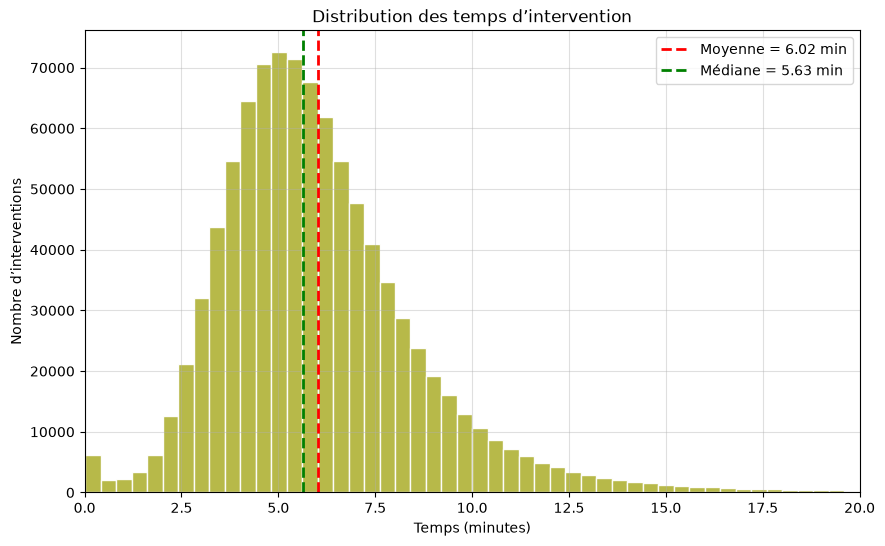

In [55]:
# Conversion du temps total d’intervention en minutes
temps_intervention = (
    LFB_MOB.loc[
        LFB_MOB["AttendanceTimeSeconds"] > 0,
        "AttendanceTimeSeconds"
    ] / 60
)

moyenne_temps = temps_intervention.mean()
mediane_temps = temps_intervention.median()

plt.figure(figsize=(10, 6))

plt.hist(
    temps_intervention,
    bins=50,
    color="#B3B53F",
    edgecolor="white",
    alpha=0.95
)

plt.axvline(
    moyenne_temps,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {moyenne_temps:.2f} min"
)

plt.axvline(
    mediane_temps,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Médiane = {mediane_temps:.2f} min"
)

plt.title("Distribution des temps d’intervention")
plt.xlabel("Temps (minutes)")
plt.ylabel("Nombre d’interventions")
plt.xlim(0, 20)
plt.grid(alpha=0.4)
plt.legend()

plt.show()

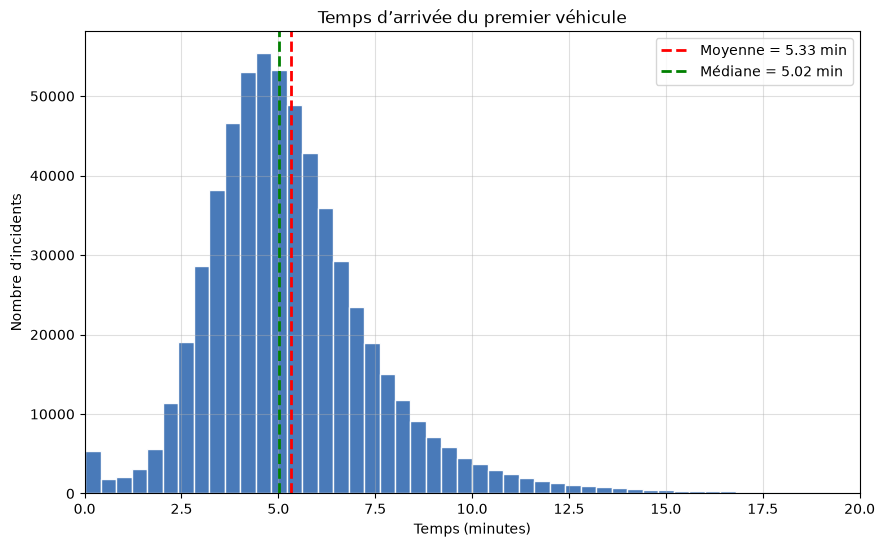

In [43]:
temps_premier_vehicule = (
    LFB_INC[
        "FirstPumpArriving_AttendanceTime"
    ]
    .dropna()
    .loc[lambda x: x > 0]
    / 60
)

moyenne_premier = temps_premier_vehicule.mean()
mediane_premier = temps_premier_vehicule.median()

plt.figure(figsize=(10, 6))

plt.hist(
    temps_premier_vehicule,
    bins=50,
    color="#3F73B5",
    edgecolor="white",
    alpha=0.95
)

plt.axvline(
    moyenne_premier,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {moyenne_premier:.2f} min"
)

plt.axvline(
    mediane_premier,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Médiane = {mediane_premier:.2f} min"
)

plt.title("Temps d’arrivée du premier véhicule")
plt.xlabel("Temps (minutes)")
plt.ylabel("Nombre d’incidents")
plt.xlim(0, 20)
plt.grid(alpha=0.4)
plt.legend()

plt.show()

### Temps d’arrivée du premier véhicule

Le premier véhicule arrive en moyenne en 5,33 minutes, avec un temps médian de 5,02 minutes.

La majorité des temps d’arrivée se concentre autour de 4 à 6 minutes. La moyenne, légèrement supérieure à la médiane, indique une distribution asymétrique vers les durées élevées : une minorité d’interventions présente des temps d’arrivée sensiblement plus longs.

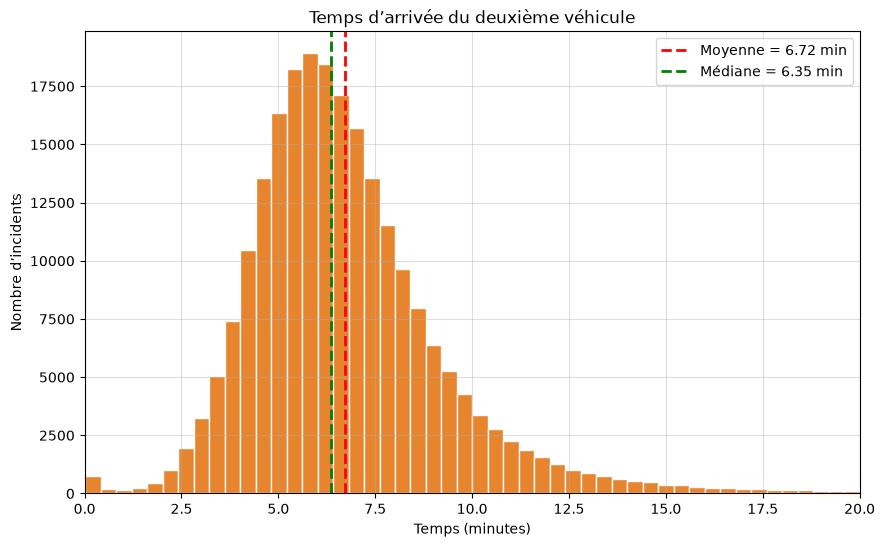

In [44]:
temps_deuxieme_vehicule = (
    LFB_INC[
        "SecondPumpArriving_AttendanceTime"
    ]
    .dropna()
    .loc[lambda x: x > 0]
    / 60
)

moyenne_deuxieme = temps_deuxieme_vehicule.mean()
mediane_deuxieme = temps_deuxieme_vehicule.median()

plt.figure(figsize=(10, 6))

plt.hist(
    temps_deuxieme_vehicule,
    bins=50,
    color="#E67E22",
    edgecolor="white",
    alpha=0.95
)

plt.axvline(
    moyenne_deuxieme,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {moyenne_deuxieme:.2f} min"
)

plt.axvline(
    mediane_deuxieme,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Médiane = {mediane_deuxieme:.2f} min"
)

plt.title("Temps d’arrivée du deuxième véhicule")
plt.xlabel("Temps (minutes)")
plt.ylabel("Nombre d’incidents")
plt.xlim(0, 20)
plt.grid(alpha=0.4)
plt.legend()

plt.show()

### Temps d’arrivée du deuxième véhicule

Parmi les incidents nécessitant un deuxième véhicule, son temps moyen d’arrivée est de 6,72 minutes et son temps médian de 6,35 minutes.

Le deuxième véhicule arrive en moyenne environ 1 minute et 23 secondes après le premier véhicule. La distribution est légèrement asymétrique vers les temps élevés, la moyenne étant supérieure à la médiane.

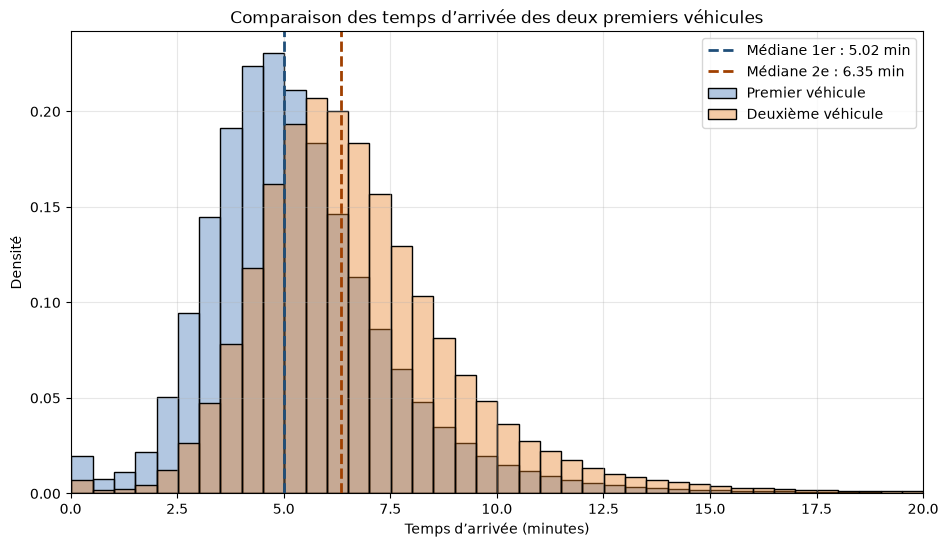

In [ ]:
plt.figure(figsize=(11, 6))

sns.histplot(
    temps_premier_vehicule,
    bins=40,
    stat="density",
    color="#3F73B5",
    alpha=0.40,
    label="Premier véhicule"
)

sns.histplot(
    temps_deuxieme_vehicule,
    bins=40,
    stat="density",
    color="#E67E22",
    alpha=0.40,
    label="Deuxième véhicule"
)

plt.axvline(
    temps_premier_vehicule.median(),
    color="#1F4E79",
    linestyle="--",
    linewidth=2,
    label=f"Médiane 1er : {temps_premier_vehicule.median():.2f} min"
)

plt.axvline(
    temps_deuxieme_vehicule.median(),
    color="#A04000",
    linestyle="--",
    linewidth=2,
    label=f"Médiane 2e : {temps_deuxieme_vehicule.median():.2f} min"
)

plt.title("Comparaison des temps d’arrivée des deux premiers véhicules")
plt.xlabel("Temps d’arrivée (minutes)")
plt.ylabel("Densité")
plt.xlim(0, 20)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### Comparaison des temps d’arrivée

La distribution du deuxième véhicule est décalée vers la droite par rapport à celle du premier, ce qui confirme un temps d’arrivée généralement plus long.

Le temps médian est de :

- 5,02 minutes pour le premier véhicule ;
- 6,35 minutes pour le deuxième véhicule.

L’écart médian est donc de 1,33 minute, soit environ 1 minute et 20 secondes.

Les distributions se chevauchent néanmoins largement, ce qui montre que, dans de nombreux incidents, les deux premiers véhicules arrivent dans des délais relativement proches.

### Temps d’arrivée moyen par incident

Un incident peut mobiliser plusieurs véhicules. Nous calculons donc, pour chaque incident, la moyenne des temps d’arrivée des ressources mobilisées.

In [50]:
temps_moyen_par_type = (
    LFB_INC
    .groupby("IncidentGroup", as_index=False)
    .agg(
        NombreIncidents=("IncidentNumber", "count"),
        TempsMoyenSecondes=(
            "FirstPumpArriving_AttendanceTime",
            "mean"
        )
    )
)

temps_moyen_par_type["TempsMoyenMinutes"] = (
    temps_moyen_par_type["TempsMoyenSecondes"] / 60
)

temps_moyen_par_type = temps_moyen_par_type.sort_values(
    "TempsMoyenMinutes",
    ascending=False
)

temps_moyen_par_type

,IncidentGroup,NombreIncidents,TempsMoyenSecondes,TempsMoyenMinutes
1,Fire,85219,331.216384,5.520273
2,Special Service,212946,329.753731,5.495896
0,False Alarm,299750,310.051480,5.167525


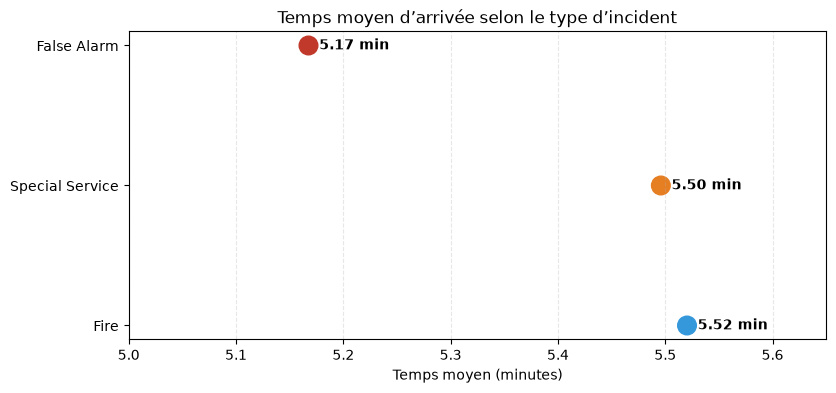

In [53]:
plt.figure(figsize=(9, 4))

couleurs = ["#3498DB", "#E67E22", "#C0392B"]

plt.scatter(
    temps_moyen_par_type["TempsMoyenMinutes"],
    temps_moyen_par_type["IncidentGroup"],
    s=180,
    c=couleurs
)

for _, ligne in temps_moyen_par_type.iterrows():
    plt.text(
        ligne["TempsMoyenMinutes"] + 0.01,
        ligne["IncidentGroup"],
        f'{ligne["TempsMoyenMinutes"]:.2f} min',
        va="center",
        fontweight="bold"
    )

plt.xlim(5.0, 5.65)
plt.title("Temps moyen d’arrivée selon le type d’incident")
plt.xlabel("Temps moyen (minutes)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.show()

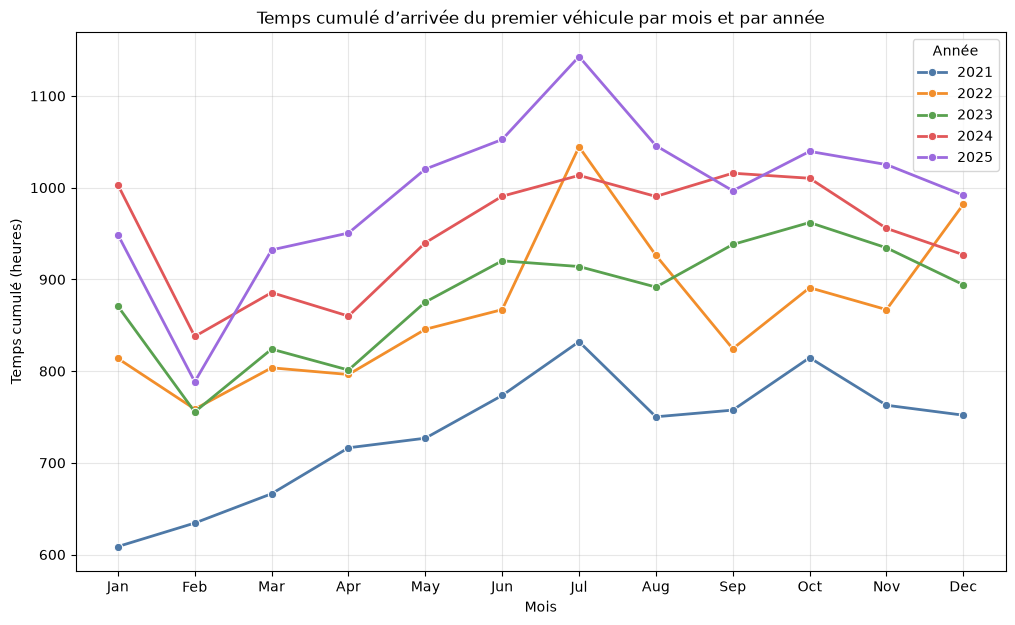

In [57]:
# Création de l’année et du numéro du mois
LFB_INC["Year"] = LFB_INC["DateOfCall"].dt.year
LFB_INC["MonthNumber"] = LFB_INC["DateOfCall"].dt.month

# Temps cumulé mensuel, converti de secondes en heures
temps_mensuel = (
    LFB_INC
    .dropna(subset=[
        "DateOfCall",
        "FirstPumpArriving_AttendanceTime"
    ])
    .groupby(
        ["Year", "MonthNumber"],
        as_index=False
    )["FirstPumpArriving_AttendanceTime"]
    .sum()
)

temps_mensuel["TotalHours"] = (
    temps_mensuel["FirstPumpArriving_AttendanceTime"] / 3600
)

# Noms des mois
mois = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

temps_mensuel["Month"] = (
    temps_mensuel["MonthNumber"].map(mois)
)

couleurs_annees = {
    2021: "#4E79A7",  # bleu
    2022: "#F28E2B",  # orange
    2023: "#59A14F",  # vert
    2024: "#E15759",  # rouge
    2025: "#9C6ADE"   # violet
}

# Graphique
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=temps_mensuel,
    x="MonthNumber",
    y="TotalHours",
    hue="Year",
    marker="o",
    linewidth=2,
    palette=couleurs_annees
)

plt.xticks(
    range(1, 13),
    [mois[num] for num in range(1, 13)]
)

plt.title(
    "Temps cumulé d’arrivée du premier véhicule par mois et par année"
)
plt.xlabel("Mois")
plt.ylabel("Temps cumulé (heures)")
plt.grid(alpha=0.3)
plt.legend(title="Année")

plt.show()

#### Évolution mensuelle du temps cumulé

Le temps cumulé d’arrivée du premier véhicule augmente globalement entre 2021 et 2025. Les niveaux les plus élevés sont fréquemment observés autour de l’été, notamment en juillet.

Cet indicateur dépend toutefois du volume mensuel d’incidents. Une hausse ne signifie donc pas nécessairement une dégradation du temps de réponse : elle peut également traduire une augmentation du nombre d’interventions.

### 5.2 Zoom sur les coûts
Cette partie analyse les coûts notionnels des interventions. Les calculs sont réalisés à partir de la table des incidents afin d’éviter le double comptage lié aux mobilisations multiples.

In [62]:
couts = LFB_INC["Notional Cost (£)"]

indicateurs_couts = pd.Series({
    "Nombre d’incidents": couts.count(),
    "Coût total (£)": couts.sum(),
    "Coût moyen (£)": couts.mean(),
    "Coût médian (£)": couts.median(),
    "Coût minimum (£)": couts.min(),
    "Coût maximum (£)": couts.max()
})

indicateurs_couts.round(2)

Nombre d’incidents    5.979150e+05
Coût total (£)        3.016688e+08
Coût moyen (£)        5.045300e+02
Coût médian (£)       3.880000e+02
Coût minimum (£)      3.460000e+02
Coût maximum (£)      4.946150e+05
dtype: float64

In [63]:
print(f"Nombre d’incidents : {int(couts.count()):,}")
print(f"Coût total : {couts.sum():,.2f} £")
print(f"Coût moyen : {couts.mean():,.2f} £")
print(f"Coût médian : {couts.median():,.2f} £")
print(f"Coût minimum : {couts.min():,.2f} £")
print(f"Coût maximum : {couts.max():,.2f} £")

Nombre d’incidents : 597,915
Coût total : 301,668,761.00 £
Coût moyen : 504.53 £
Coût médian : 388.00 £
Coût minimum : 346.00 £
Coût maximum : 494,615.00 £


In [65]:
couts_par_annee = (
    LFB_INC
    .groupby("Year", as_index=False)
    .agg(
        NombreIncidents=("IncidentNumber", "count"),
        CoutTotal=("Notional Cost (£)", "sum"),
        CoutMoyen=("Notional Cost (£)", "mean")
    )
)

couts_par_annee

,Year,NombreIncidents,CoutTotal,CoutMoyen
0,2021,102078,45239636,443.186935
1,2022,118151,55646689,470.979416
2,2023,119576,56747154,474.569763
3,2024,127513,67126109,526.425612
4,2025,130597,76909173,588.904592


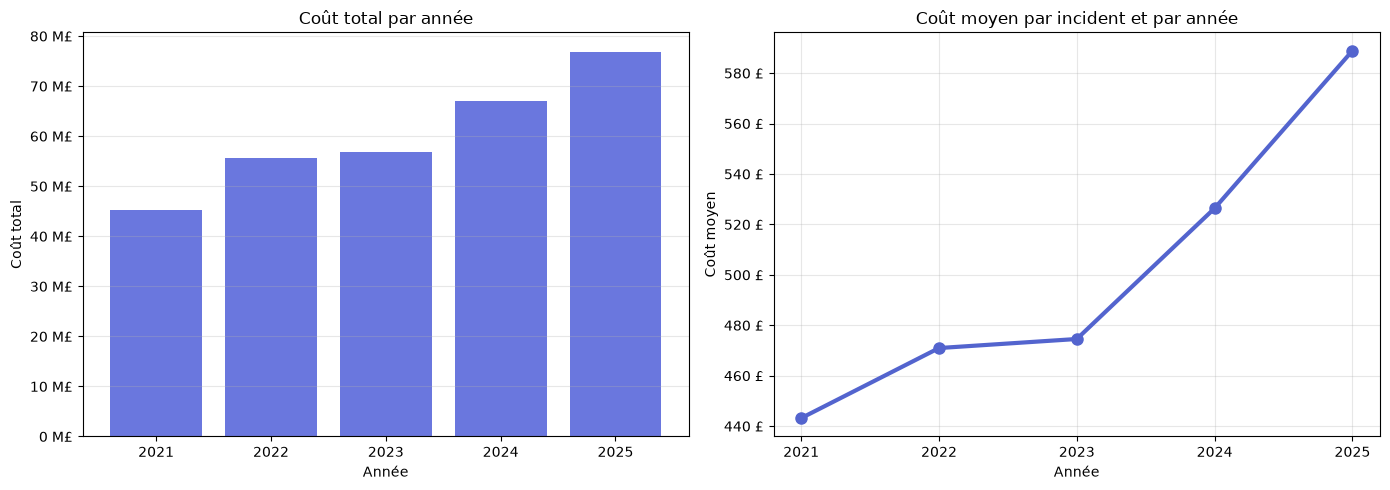

In [68]:
from matplotlib.ticker import FuncFormatter

# Années affichées comme des nombres entiers
couts_par_annee["Year"] = (
    couts_par_annee["Year"].astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coût total : graphique en colonnes
axes[0].bar(
    couts_par_annee["Year"].astype(str),
    couts_par_annee["CoutTotal"],
    color="#6A77DE"
)

axes[0].set_title("Coût total par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Coût total")
axes[0].grid(axis="y", alpha=0.3)

axes[0].yaxis.set_major_formatter(
    FuncFormatter(
        lambda valeur, position:
        f"{valeur / 1_000_000:.0f} M£"
    )
)

# Coût moyen : graphique en courbe
axes[1].plot(
    couts_par_annee["Year"].astype(str),
    couts_par_annee["CoutMoyen"],
    marker="o",
    color="#5364CE",
    linewidth=3,
    markersize=8
)

axes[1].set_title("Coût moyen par incident et par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Coût moyen")
axes[1].grid(alpha=0.3)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(
        lambda valeur, position:
        f"{valeur:,.0f} £"
    )
)

plt.tight_layout()
plt.show()

#### Interprétation

Le coût total des interventions augmente progressivement entre 2021 et 2025, passant d’environ 45 millions de livres à près de 77 millions de livres.

Le coût moyen par incident augmente également, avec une hausse plus marquée à partir de 2024. Il passe d’environ 443 £ en 2021 à 588 £ en 2025.

Cependant, l’évolution du coût total dépend aussi du nombre d’incidents enregistrés chaque année. Une analyse du volume annuel d’incidents est donc nécessaire avant de conclure sur l’origine de cette hausse.

### 5.3 Zomm sur les incidents
Cette partie étudie la répartition des incidents selon leur catégorie afin d’identifier les interventions les plus fréquentes.

In [69]:
repartition_incidents = (
    LFB_INC["IncidentGroup"]
    .value_counts()
    .reset_index()
)

repartition_incidents.columns = [
    "Type d’incident",
    "Nombre d’incidents"
]

repartition_incidents

,Type d’incident,Nombre d’incidents
0,False Alarm,299750
1,Special Service,212946
2,Fire,85219


In [70]:
repartition_incidents["Pourcentage"] = (
    repartition_incidents["Nombre d’incidents"]
    / repartition_incidents["Nombre d’incidents"].sum()
    * 100
).round(2)

repartition_incidents

,Type d’incident,Nombre d’incidents,Pourcentage
0,False Alarm,299750,50.13
1,Special Service,212946,35.61
2,Fire,85219,14.25


#### Interprétation

Les fausses alertes représentent environ la moitié des incidents enregistrés. Les interventions de type *Special Service* constituent un peu plus d’un tiers des incidents, tandis que les incendies représentent environ 14 % du total.

La forte proportion de fausses alertes constitue un enjeu opérationnel important, car elles mobilisent des véhicules et des équipes qui pourraient être nécessaires sur de véritables urgences.

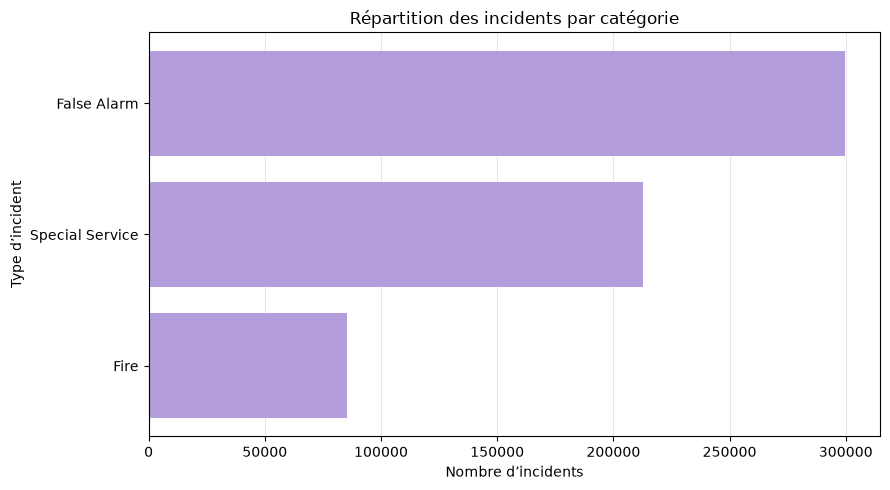

In [71]:
plt.figure(figsize=(9, 5))

plt.barh(
    repartition_incidents["Type d’incident"],
    repartition_incidents["Nombre d’incidents"],
    color="#B39DDB"
)

plt.title("Répartition des incidents par catégorie")
plt.xlabel("Nombre d’incidents")
plt.ylabel("Type d’incident")
plt.grid(axis="x", alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [74]:
incidents_par_annee = (
    LFB_INC
    .groupby(["Year", "IncidentGroup"])
    .size()
    .reset_index(name="NombreIncidents")
)

incidents_par_annee["Year"] = incidents_par_annee["Year"].astype(int)

incidents_par_annee.head()

,Year,IncidentGroup,NombreIncidents
0,2021,False Alarm,53039
1,2021,Fire,14795
2,2021,Special Service,34244
3,2022,False Alarm,58870
4,2022,Fire,19045


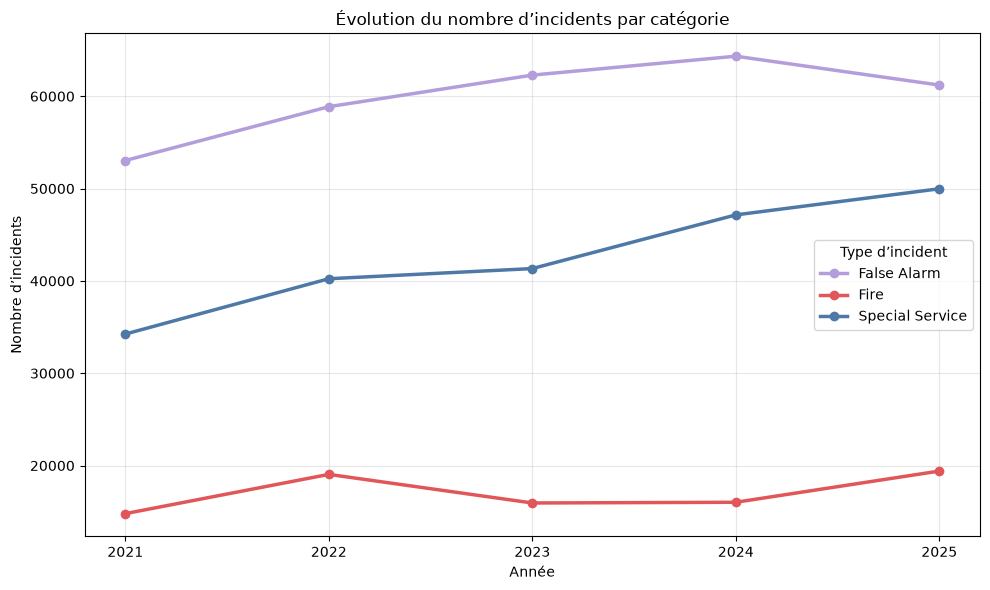

In [75]:
couleurs_incidents = {
    "False Alarm": "#B39DDB",
    "Special Service": "#4E79A7",
    "Fire": "#E15759"
}

plt.figure(figsize=(10, 6))

for categorie in incidents_par_annee["IncidentGroup"].unique():
    donnees = incidents_par_annee[
        incidents_par_annee["IncidentGroup"] == categorie
    ]

    plt.plot(
        donnees["Year"],
        donnees["NombreIncidents"],
        marker="o",
        linewidth=2.5,
        label=categorie,
        color=couleurs_incidents[categorie]
    )

plt.title("Évolution du nombre d’incidents par catégorie")
plt.xlabel("Année")
plt.ylabel("Nombre d’incidents")
plt.xticks(incidents_par_annee["Year"].unique())
plt.grid(alpha=0.3)
plt.legend(title="Type d’incident")

plt.tight_layout()
plt.show()

#### Interprétation

Les fausses alertes constituent la première catégorie d’incidents sur toute la période. Leur nombre augmente entre 2021 et 2024, avant de diminuer légèrement en 2025.

Les interventions de type *Special Service* progressent régulièrement, passant d’environ 34 000 incidents en 2021 à près de 50 000 en 2025. Il s’agit de la hausse la plus continue observée.

Le nombre d’incendies reste plus faible et relativement stable, malgré des hausses en 2022 et en 2025.

L’augmentation globale de l’activité semble donc être principalement portée par les interventions de type *Special Service*, plutôt que par les incendies.

### 6. Conclusion provisoire

Cette première analyse exploratoire permet de dégager les principales tendances concernant les incidents, les temps d’arrivée des véhicules et les coûts d’intervention de la London Fire Brigade.

Les résultats présentés constituent une première interprétation descriptive des données. Ils permettent notamment d’identifier l’évolution des différentes catégories d’incidents, la progression des coûts et les écarts entre les temps d’arrivée des deux premiers véhicules.

Les données préparées dans ce notebook seront ensuite exploitées dans Power BI afin de réaliser une analyse plus approfondie et interactive. Cette seconde étape permettra notamment de croiser les indicateurs selon les années, les types d’incidents, les zones géographiques et les coûts d’intervention.

Les conclusions définitives seront donc formulées après l’analyse détaillée réalisée dans Power BI.